In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
omega_r = 8.5e-5
omega_m = 0.3111
omega_l = 0.6889
hubble = 0.6766
omega_c  = 1.0-omega_r-omega_m-omega_l

# z = np.linspace(0.0, 6.0, 200)
# a = 1/(1+z)
# a = a[::-1]
a = np.linspace(0.14,1.0,200)
c1 = 0.5
c2 = 0.5
c3 = 0.5
expf = np.sqrt (omega_r/a**4 + omega_m/a**3 + omega_l + omega_c/a**2)

print(f"{a[0]} {a[-1]}")

0.14 1.0


In [3]:
def model (x,c1,c2,c3) :
    h0 = 0.6766
    cheb_poly = np.polynomial.chebyshev.Chebyshev([c1,c2,c3], domain=[0.14285714285714285,1.0])
    return h0*cheb_poly(x)

In [4]:
params, covariance = curve_fit(model,a,expf)
c1,c2,c3 = params
print(params)

[ 4.38245453 -4.06565165  2.50775156]


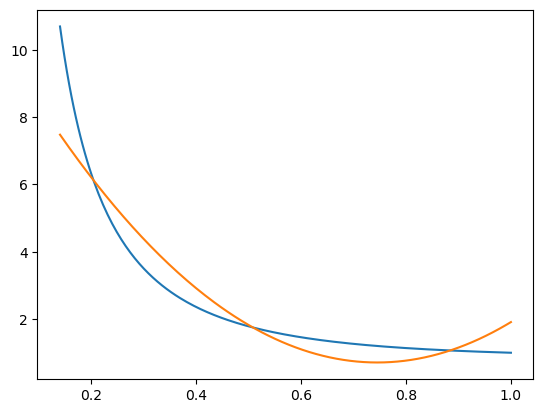

In [40]:
plt.plot(a,expf)
plt.plot(a,model(a,c1,c2,c3))

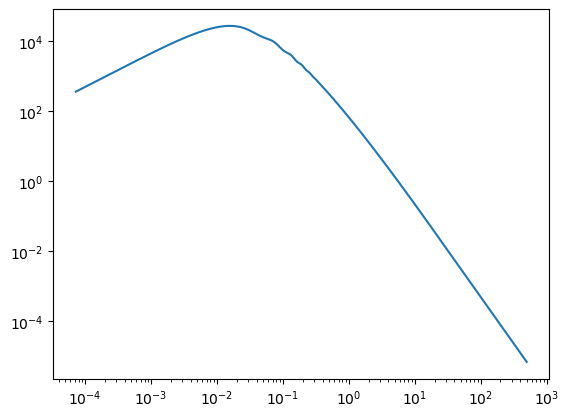

In [12]:
pm = np.loadtxt("pm.txt")
k = np.loadtxt("k_h.txt")
pm = pm[::-1]
pm = pm[0]

plt.loglog(k,pm)

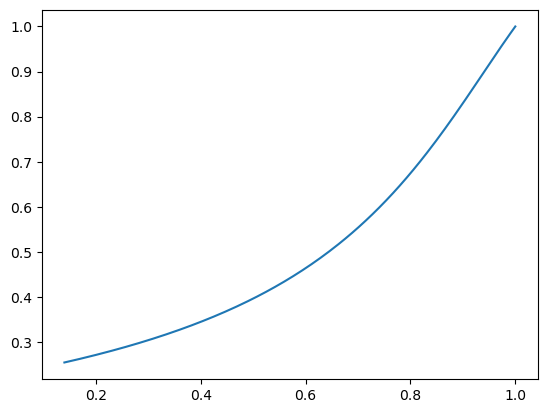

In [13]:
dpl = np.loadtxt("dpl.txt")
plt.plot(a,dpl)

In [ ]:
data = np.loadtxt("output_multinest.txt", skiprows=226)
omega_m = data[:,1]
omch2 = data[:,2]
print(omega_m.shape)

(1500,)


(1500, 16)

Text(0, 0.5, 'omega_m')

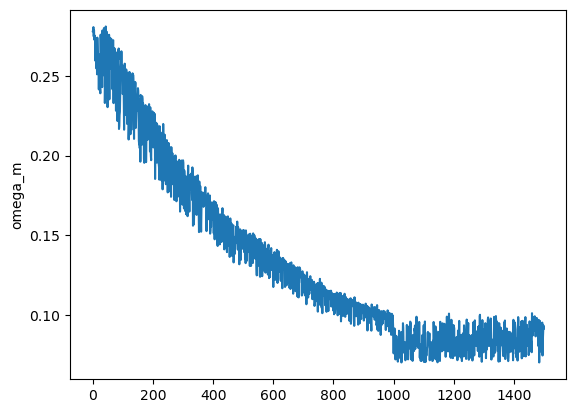

In [27]:
plt.plot(omega_m)
plt.ylabel("omega_m")

Text(0, 0.5, 'omch2')

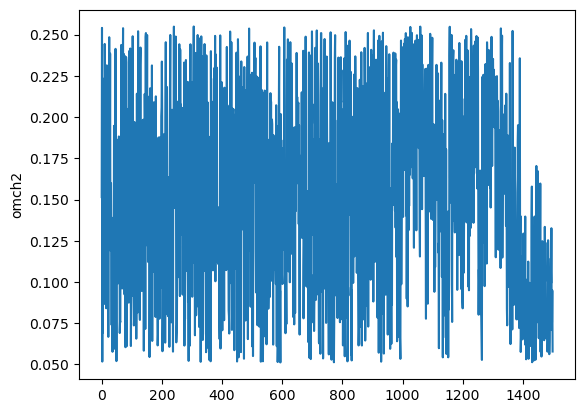

In [28]:
plt.plot(omch2)
plt.ylabel("omch2")